In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [2]:
dataset_path = "colored_images"

In [5]:
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)
img_size = 224
batch_size = 32

In [6]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

Found 2931 images belonging to 5 classes.


In [23]:
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 731 images belonging to 5 classes.


In [8]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [9]:
model = models.Sequential([
    
    base_model,
    
    layers.GlobalAveragePooling2D(),
    
    layers.BatchNormalization(),
    
    layers.Dense(128, activation='relu'),
    
    layers.Dropout(0.5),
    
    layers.Dense(5, activation='softmax')
])

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,219,304 (16.10 MB)

 Trainable params: 167,173 (653.02 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [12]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.6905 - loss: 0.9698 - val_accuracy: 0.7784 - val_loss: 0.7560
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.7383 - loss: 0.7312 - val_accuracy: 0.7647 - val_loss: 0.6555
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.7721 - loss: 0.6699 - val_accuracy: 0.7907 - val_loss: 0.5863
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.7758 - loss: 0.6129 - val_accuracy: 0.8057 - val_loss: 0.5387
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.7827 - loss: 0.5966 - val_accuracy: 0.8057 - val_loss: 0.5239
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.7885 - loss: 0.5510 - val_accuracy: 0.7975 - val_loss: 0.5283
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.8134 - loss: 0.5271 - val_accuracy: 0.8057 - val_loss: 0.5192
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.8154 - loss: 0.5079 - val_accuracy: 0.7934 - v

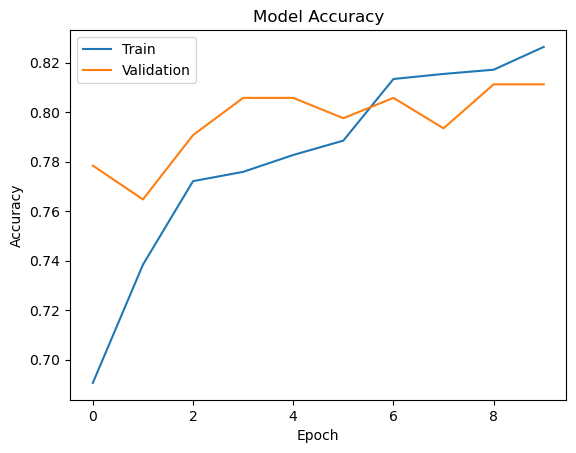

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

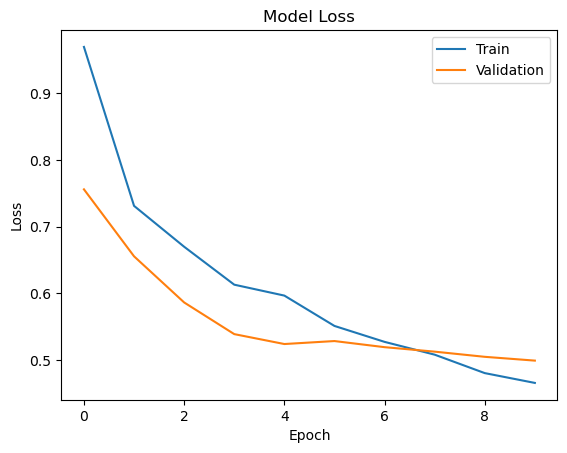

In [14]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [15]:
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 937ms/step - accuracy: 0.8030 - loss: 0.5006
Validation Accuracy: 0.803009569644928
Validation Loss: 0.5005500912666321


In [16]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

In [17]:
import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
history_finetune = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.7240 - loss: 0.7519 - val_accuracy: 0.7989 - val_loss: 0.5375
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.7489 - loss: 0.6616 - val_accuracy: 0.7715 - val_loss: 0.5591
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.7523 - loss: 0.6521 - val_accuracy: 0.7811 - val_loss: 0.5741
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.7738 - loss: 0.6243 - val_accuracy: 0.7880 - val_loss: 0.5825
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.7786 - loss: 0.5821 - val_accuracy: 0.7674 - val_loss: 0.5762
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.7854 - loss: 0.5790 - val_accuracy: 0.7907 - val_loss: 0.5630
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.7816 - loss: 0.5871 - val_accuracy: 0.7811 - val_loss: 0.5701
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.7902 - loss: 0.5658 - val_accuracy: 0.7948 - v

In [24]:
import numpy as np

# reset generator
val_data.reset()

predictions = model.predict(val_data)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_data.classes
class_labels = list(val_data.class_indices.keys())

23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 929ms/step


In [25]:
from sklearn.metrics import classification_report

report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
)

print(report)

                precision    recall  f1-score   support

          Mild       0.56      0.45      0.50        74
      Moderate       0.65      0.81      0.72       199
         No_DR       0.96      0.98      0.97       361
Proliferate_DR       0.54      0.32      0.40        59
        Severe       0.33      0.18      0.24        38

      accuracy                           0.78       731
     macro avg       0.61      0.55      0.57       731
  weighted avg       0.77      0.78      0.77       731



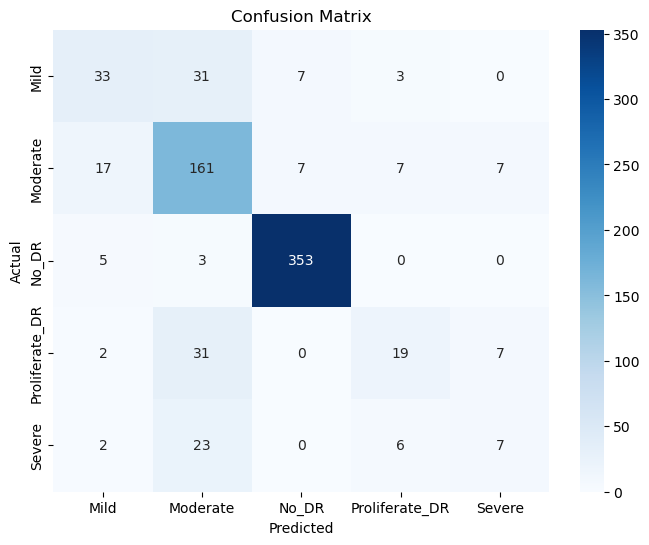

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [28]:
model.save("retinopathy_model.h5")

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

img_size = 224
batch_size = 32
dataset_path = r"C:\Users\shikh\diabetic-retinopathy-detection\colored_images"   

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 731 images belonging to 5 classes.


In [14]:
from tensorflow.keras.models import load_model

model = load_model("retinopathy_model.h5")

23/23 ━━━━━━━━━━━━━━━━━━━━ 24s 940ms/step


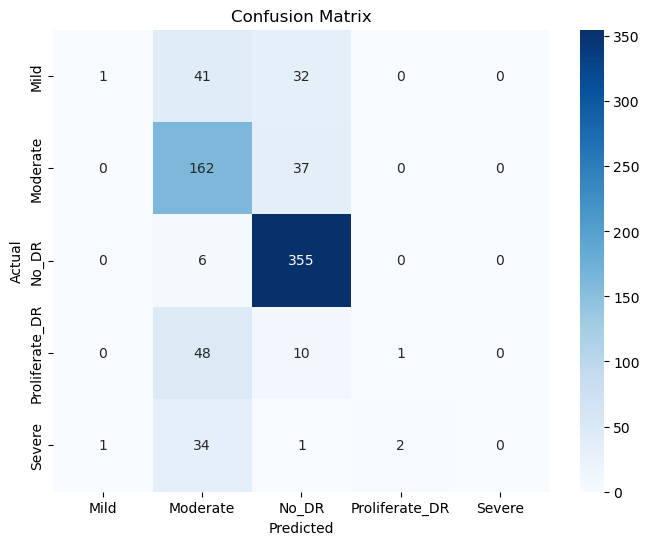

In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

val_data.reset()

predictions = model.predict(val_data)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_data.classes
class_labels = list(val_data.class_indices.keys())

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")

plt.show()